In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\haryi\Downloads\Data Cleaning + Dashboard Project\Data\ecommerce_dataset_updated.csv")
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [4]:
df = pd.read_csv(r"C:\Users\haryi\Downloads\Data Cleaning + Dashboard Project\Data\ecommerce_dataset_updated.csv")

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   str    
 1   Product_ID        3660 non-null   str    
 2   Category          3660 non-null   str    
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   str    
 7   Purchase_Date     3660 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 228.9 KB


,Price (Rs.),Discount (%),Final_Price(Rs.)
count,3660.000000,3660.000000,3660.000000
mean,254.800675,18.825137,206.906579
std,141.682621,14.731338,122.687844
min,10.090000,0.000000,5.890000
25%,134.012500,5.000000,104.512500
50%,253.845000,15.000000,199.185000
75%,377.595000,25.000000,304.117500
max,499.960000,50.000000,496.820000


In [5]:
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"],format="%d-%m-%Y")
df["Purchase_Date"].head()

0   2024-11-12
1   2024-02-09
2   2024-09-01
3   2024-04-01
4   2024-09-27
Name: Purchase_Date, dtype: datetime64[us]

In [6]:
df["Revenue"] = df["Final_Price(Rs.)"]
df["Revenue"].head()

0     31.05
1    186.23
2    237.76
3    129.89
4    195.84
Name: Revenue, dtype: float64

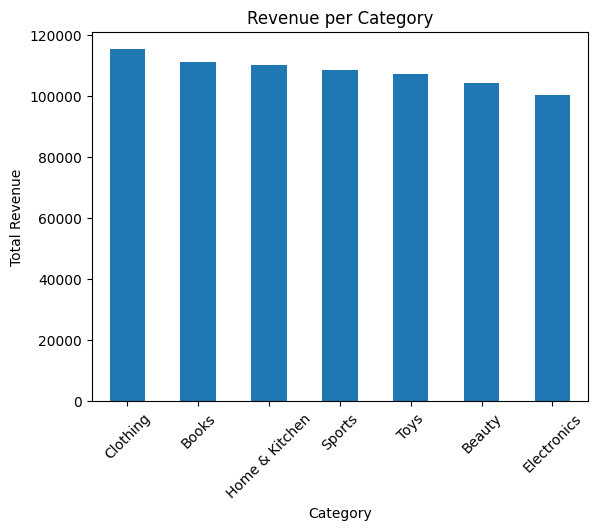

In [7]:
revenue_cat = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

revenue_cat.plot(kind="bar")
plt.title("Revenue per Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

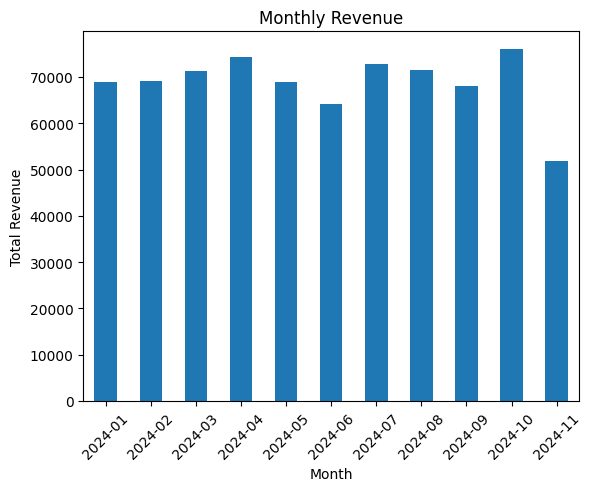

In [8]:
# Convert Purchase_Date to datetime
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"], format="%m-%d-%Y")

# Create Month column
df["Month"] = df["Purchase_Date"].dt.to_period("M")

# Calculate monthly revenue
monthly_revenue = df.groupby("Month")["Final_Price(Rs.)"].sum()

monthly_revenue.head()

monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

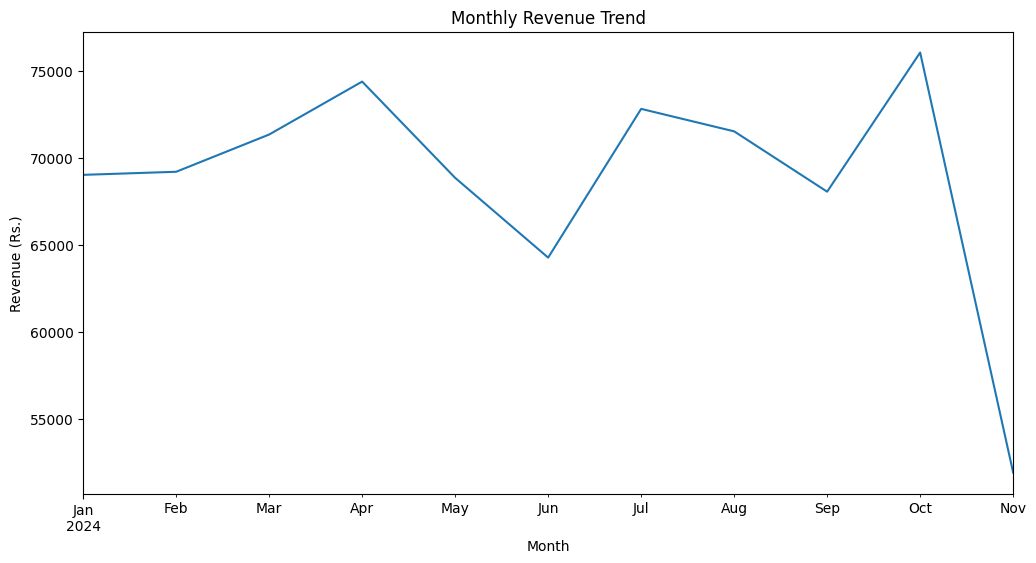

In [9]:
plt.figure(figsize=(12,6))
monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Rs.)")

plt.show()

Seasons

Winter: Decemeber, January, February

Spring: March, April, May

Summer: June, July, August

Autumn: September, October, November

Are sales increasing or decreasing?

Sales are decreasing but it can be recoverable.

Are there seasonal spikes?

Usually the beginning of every season has a down spike, and at the middle of every season has a spike up.

Best season was spring. Worse season was Autumn.

Which months perform best?

Best months: April, July, October

Worst months: June, September, November

In [10]:
payment_counts = df["Payment_Method"].value_counts()
payment_counts

Payment_Method
Credit Card         760
UPI                 757
Debit Card          731
Net Banking         716
Cash on Delivery    696
Name: count, dtype: int64

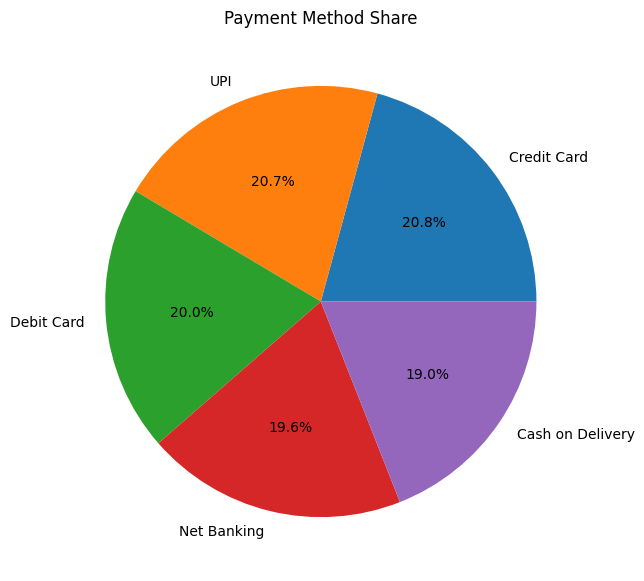

In [11]:
plt.figure(figsize=(7,7))

payment_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Method Share")
plt.ylabel("")  # removes extra label
plt.show()

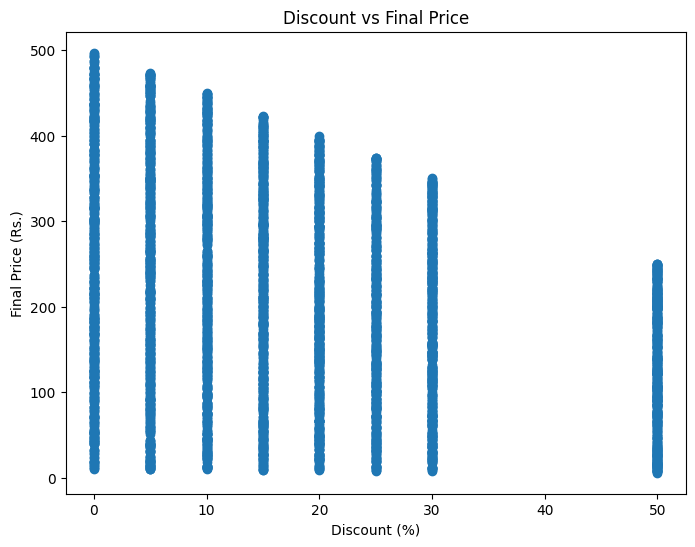

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(df["Discount (%)"], df["Final_Price(Rs.)"])

plt.title("Discount vs Final Price")
plt.xlabel("Discount (%)")
plt.ylabel("Final Price (Rs.)")

plt.show()

Do higher discounts lead to higher spending?

No

Is there a “sweet spot” discount?

20% seems to be reasonable.

Do extreme discounts reduce revenue?

Yes, the higher the discount the lower the revenue.

In [13]:
# Sum revenue per category
revenue_by_category = df.groupby("Category")["Final_Price(Rs.)"].sum().sort_values(ascending=False)
revenue_by_category

Category
Clothing          115314.84
Books             111149.35
Home & Kitchen    110328.08
Sports            108518.79
Toys              107289.69
Beauty            104215.10
Electronics       100462.23
Name: Final_Price(Rs.), dtype: float64

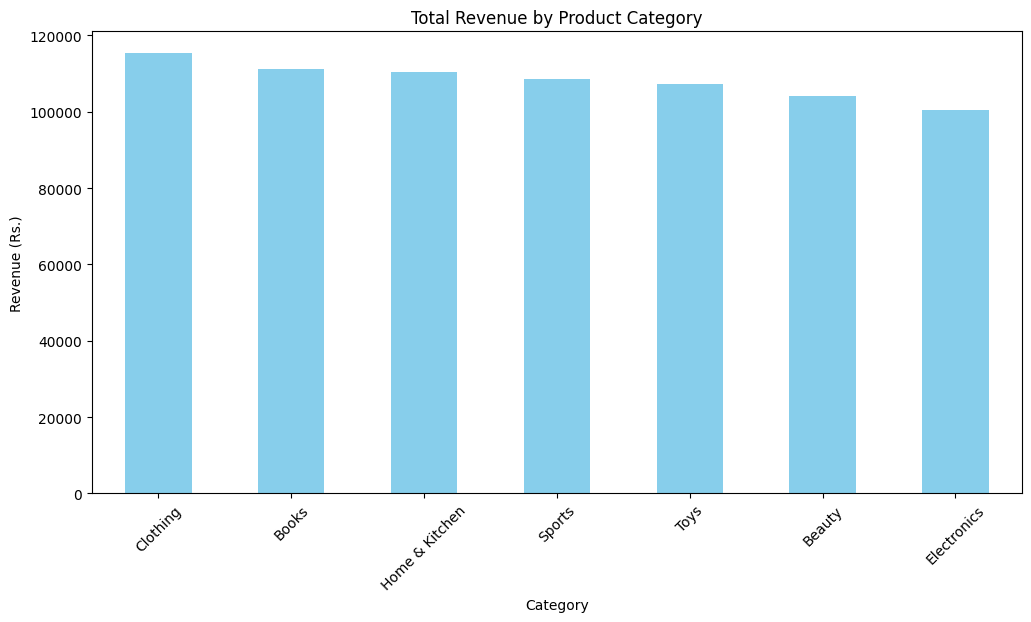

In [14]:
plt.figure(figsize=(12,6))
revenue_by_category.plot(kind="bar", color="skyblue")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (Rs.)")
plt.xticks(rotation=45)

plt.show()

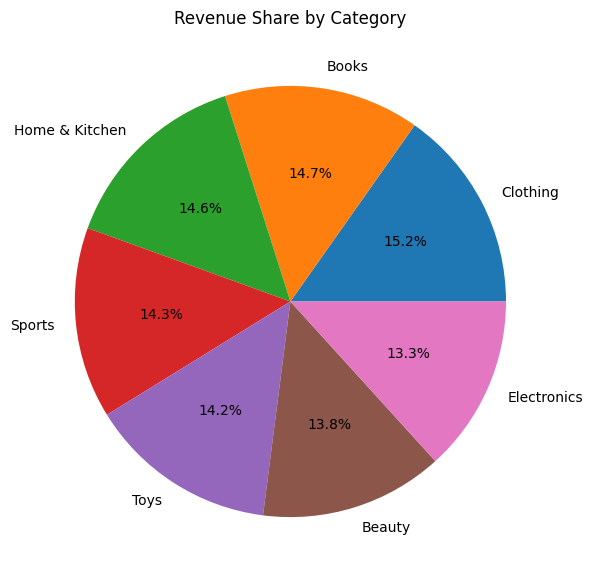

In [15]:
plt.figure(figsize=(7,7))
revenue_by_category.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue Share by Category")
plt.ylabel("")  # remove extra y-label
plt.show()

Clothing contributed the highest revenue, followed by Books and Home & Kitchen, indicating where the company should focus marketing and inventory efforts.

In [16]:
purchases_per_user = df["User_ID"].value_counts()
purchases_per_user.head()

User_ID
337c166f    1
d38a19bf    1
d7f5f0b0    1
395d4994    1
a83c145c    1
Name: count, dtype: int64

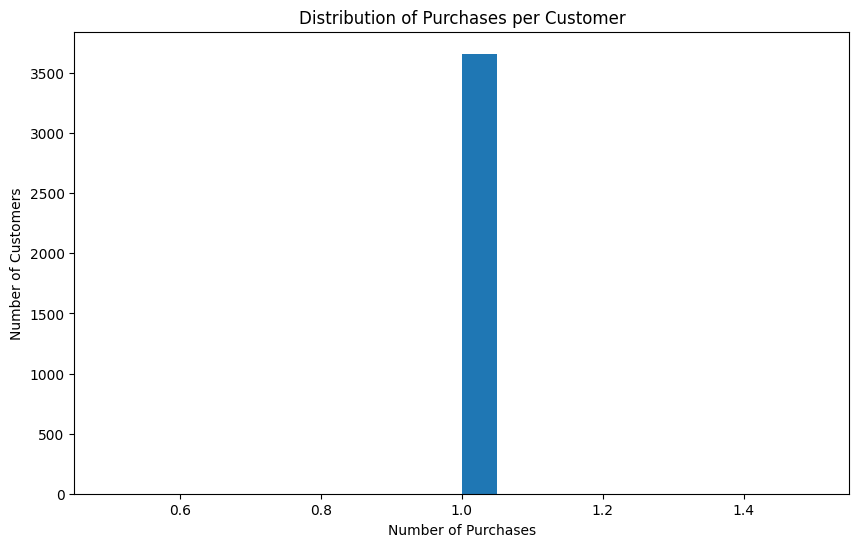

In [17]:
plt.figure(figsize=(10,6))
purchases_per_user.plot(kind="hist", bins=20)

plt.title("Distribution of Purchases per Customer")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
revenue_per_user = df.groupby("User_ID")["Final_Price(Rs.)"].sum()

avg_revenue_per_user = revenue_per_user.mean()
avg_revenue_per_user

np.float64(206.90657923497267)

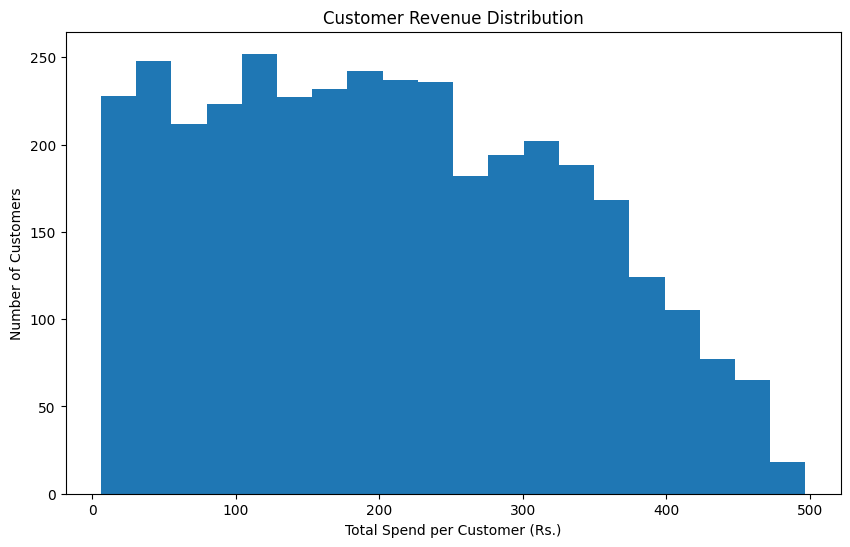

In [21]:
plt.figure(figsize=(10,6))
revenue_per_user.plot(kind="hist", bins=20)

plt.title("Customer Revenue Distribution")
plt.xlabel("Total Spend per Customer (Rs.)")
plt.ylabel("Number of Customers")

plt.show()

In [29]:
# Revenue saved from discount
df["Revenue_Saved"] = df["Price (Rs.)"] - df["Final_Price(Rs.)"]

# Discount buckets for analysis
df["Discount_Bucket"] = pd.cut(
    df["Discount (%)"],
    bins=[-1,0,10,20,30,50],
    labels=["No Discount","1-10%","11-20%","21-30%","30%+"]
)

# Month + Year for time analysis
df["Month"] = df["Purchase_Date"].dt.to_period("M").astype(str)

# Month name (nicer visuals)
df["Month_Name"] = df["Purchase_Date"].dt.strftime("%B")

df

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date,Revenue,Month,Revenue_Saved,Discount_Bucket,Month_Name
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,2024-11-12,31.05,2024-11,5.48,11-20%,November
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,2024-02-09,186.23,2024-02,46.56,11-20%,February
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,2024-09-01,237.76,2024-09,79.26,21-30%,September
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,2024-04-01,129.89,2024-04,43.30,21-30%,April
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,2024-09-27,195.84,2024-09,48.96,11-20%,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,67abda0a,28714133-6,Beauty,486.79,0,486.79,UPI,2024-05-14,486.79,2024-05,0.00,No Discount,May
3656,34ebc1a0,08838c2c-9,Toys,212.87,15,180.94,Cash on Delivery,2024-11-19,180.94,2024-11,31.93,11-20%,November
3657,1defd3b1,c39a4f16-6,Home & Kitchen,389.76,0,389.76,Net Banking,2024-08-07,389.76,2024-08,0.00,No Discount,August
3658,0611293d,b4f67f96-9,Electronics,447.66,30,313.36,UPI,2024-05-21,313.36,2024-05,134.30,21-30%,May


In [30]:
df.to_csv("ecommerce_analysis_ready.csv", index=False)